# Prix des produits alimentaires au Bénin : quand et où acheter ?

**Source :** Programme alimentaire mondial (PAM), base de données des prix alimentaires, publiée sur HDX (Nations unies). Données de janvier 2002 à juillet 2026.

**Public visé :** importateurs, grossistes, semi-grossistes, supermarchés, commerçants et ONG de sécurité alimentaire.

**Questions auxquelles ce projet répond :**
1. **Quand acheter ?** À quelle période de l'année les prix sont-ils les plus bas ?
2. **Où acheter ?** Dans quels marchés les prix sont-ils les plus bas ?
3. **Quels produits sont risqués ?** Lesquels changent de prix brutalement ?
4. **Produits importés ou locaux ?** Lesquels sont les plus instables ?
5. **À quoi s'attendre ?** Quelle évolution des prix dans les prochains mois ?

## 1. Chargement des données

In [1]:
# Étape 1 : charger les deux fichiers
from google.colab import files
import pandas as pd

files.upload()   # choisis les 2 fichiers CSV dans Téléchargements

prix = pd.read_csv("wfp_food_prices_ben.csv")
marches = pd.read_csv("wfp_markets_ben.csv")

print("Nombre de lignes et de colonnes :", prix.shape)
prix.head()

Saving wfp_food_prices_ben.csv to wfp_food_prices_ben.csv
Saving wfp_markets_ben.csv to wfp_markets_ben.csv
Nombre de lignes et de colonnes : (142759, 16)


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2002-01-15,Alibori,Malanville,Malanville (CBM),1044,11.86,3.38,cereals and tubers,Maize,51,KG,actual,Wholesale,XOF,145.00,0.34
1,2002-01-15,Alibori,Malanville,Malanville (CBM),1044,11.86,3.38,cereals and tubers,Millet,73,KG,actual,Wholesale,XOF,145.00,0.34
2,2002-01-15,Alibori,Malanville,Malanville (CBM),1044,11.86,3.38,cereals and tubers,Rice (imported),64,KG,actual,Wholesale,XOF,293.33,0.70
3,2002-01-15,Alibori,Malanville,Malanville (CBM),1044,11.86,3.38,cereals and tubers,Sorghum,65,KG,actual,Wholesale,XOF,141.67,0.34
4,2003-01-15,Alibori,Malanville,Malanville (CBM),1044,11.86,3.38,cereals and tubers,Maize,51,KG,actual,Wholesale,XOF,106.00,0.25


## 2. Diagnostic des données
Avant toute analyse, on vérifie la qualité des données : la période couverte, le nombre de marchés et de produits, les valeurs manquantes, et la répartition entre prix de gros et prix de détail.

In [2]:
# Étape 2 : diagnostic des données
print("Période :", prix["date"].min(), "à", prix["date"].max())
print("Nombre de marchés :", prix["market"].nunique())
print("Nombre de produits :", prix["commodity"].nunique())
print("\nValeurs manquantes par colonne :")
print(prix.isna().sum())
print("\nType de prix :")
print(prix["pricetype"].value_counts())

Période : 2002-01-15 à 2026-07-15
Nombre de marchés : 51
Nombre de produits : 53

Valeurs manquantes par colonne :
date            0
admin1          0
admin2          0
market          0
market_id       0
latitude        0
longitude       0
category        0
commodity       0
commodity_id    0
unit            0
priceflag       0
pricetype       0
currency        0
price           0
usdprice        0
dtype: int64

Type de prix :
pricetype
Retail       142432
Wholesale       327
Name: count, dtype: int64


**Constats du diagnostic :**
- Aucune valeur manquante : les données sont propres.
- Les relevés sont rares avant 2019, puis nombreux (7 000 à 22 000 prix par an). L'analyse porte donc sur la période **2019 à 2026**.
- 99,8 % des prix sont des **prix de détail**. Les prix de gros étant trop rares, l'analyse porte sur les prix de détail, qui reflètent les tendances du marché et le prix payé par le consommateur final.

## 3. Préparation des données

In [3]:
# Étape 3 : garder les prix de détail de 2019 à 2026
prix["date"] = pd.to_datetime(prix["date"])
df = prix[(prix["date"].dt.year >= 2019) & (prix["pricetype"] == "Retail")].copy()

df["annee"] = df["date"].dt.year
df["mois"] = df["date"].dt.month

print("Lignes gardées :", len(df))
print("\nLes 15 produits les plus suivis :")
print(df["commodity"].value_counts().head(15))

Lignes gardées : 138895

Les 15 produits les plus suivis :
commodity
Cassava meal (gari)       4162
Rice (imported)           4160
Beans (white)             4154
Onions                    4142
Maize (white)             4139
Oil (groundnut)           4112
Soybeans                  4108
Oil (palm)                4058
Sorghum (red)             4047
Tomatoes                  4036
Peppers (red, dry)        3950
Cassava meal (tapioca)    3942
Groundnuts (Bambara)      3915
Fish (fresh, silvi)       3883
Oranges                   3824
Name: count, dtype: int64


## 4. Quand acheter ? La saisonnalité des prix
Pour chaque produit, le prix moyen de chaque année vaut 100. Un mois à 90 signifie que le produit y est 10 % moins cher que la moyenne de l'année ; un mois à 120, 20 % plus cher. La moyenne est calculée sur 2019-2025 (années complètes). Cette méthode neutralise l'inflation et fait apparaître les meilleures périodes d'achat.

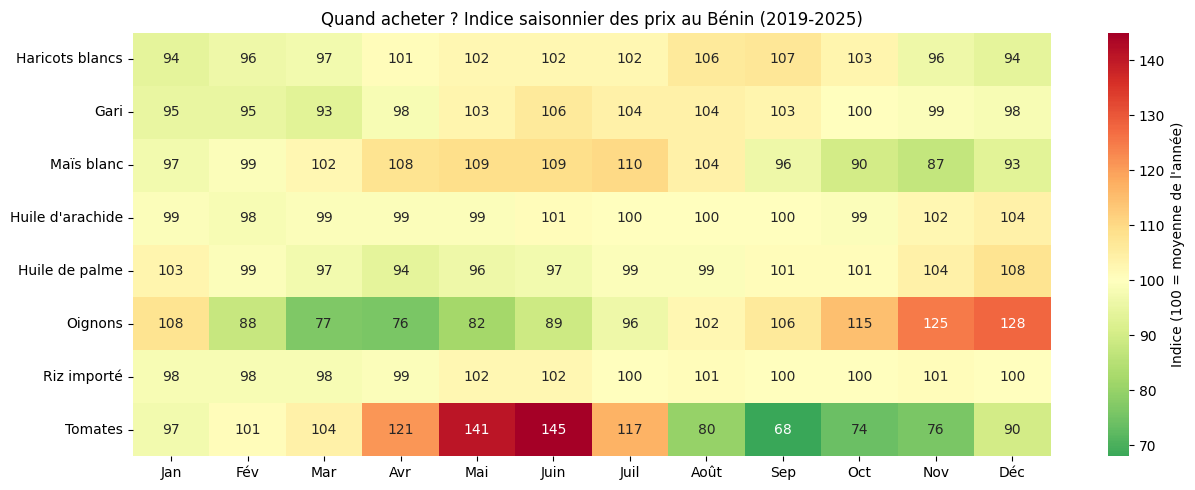

In [4]:
# Étape 4 : indice saisonnier des prix (100 = moyenne de l'année)
import matplotlib.pyplot as plt
import seaborn as sns

produits = {"Rice (imported)": "Riz importé", "Maize (white)": "Maïs blanc",
            "Cassava meal (gari)": "Gari", "Beans (white)": "Haricots blancs",
            "Oil (palm)": "Huile de palme", "Oil (groundnut)": "Huile d'arachide",
            "Onions": "Oignons", "Tomatoes": "Tomates"}

d = df[df["commodity"].isin(produits) & (df["annee"] <= 2025)]
m = d.groupby(["commodity", "annee", "mois"])["price"].mean().reset_index()
m["moyenne_annee"] = m.groupby(["commodity", "annee"])["price"].transform("mean")
m["indice"] = m["price"] / m["moyenne_annee"] * 100

saison = m.groupby(["commodity", "mois"])["indice"].mean().unstack().round(0)
saison.index = saison.index.map(produits)
saison.columns = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
                  "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]

plt.figure(figsize=(13, 5))
sns.heatmap(saison, annot=True, fmt=".0f", cmap="RdYlGn_r", center=100,
            cbar_kws={"label": "Indice (100 = moyenne de l'année)"})
plt.title("Quand acheter ? Indice saisonnier des prix au Bénin (2019-2025)")
plt.xlabel(""); plt.ylabel("")
plt.tight_layout()
plt.show()

**Lecture :** les produits frais (tomates, oignons) et le maïs ont de fortes variations saisonnières. Le riz importé et l'huile d'arachide ont des prix stables toute l'année. Le graphique suivant chiffre l'économie possible en achetant au meilleur mois.

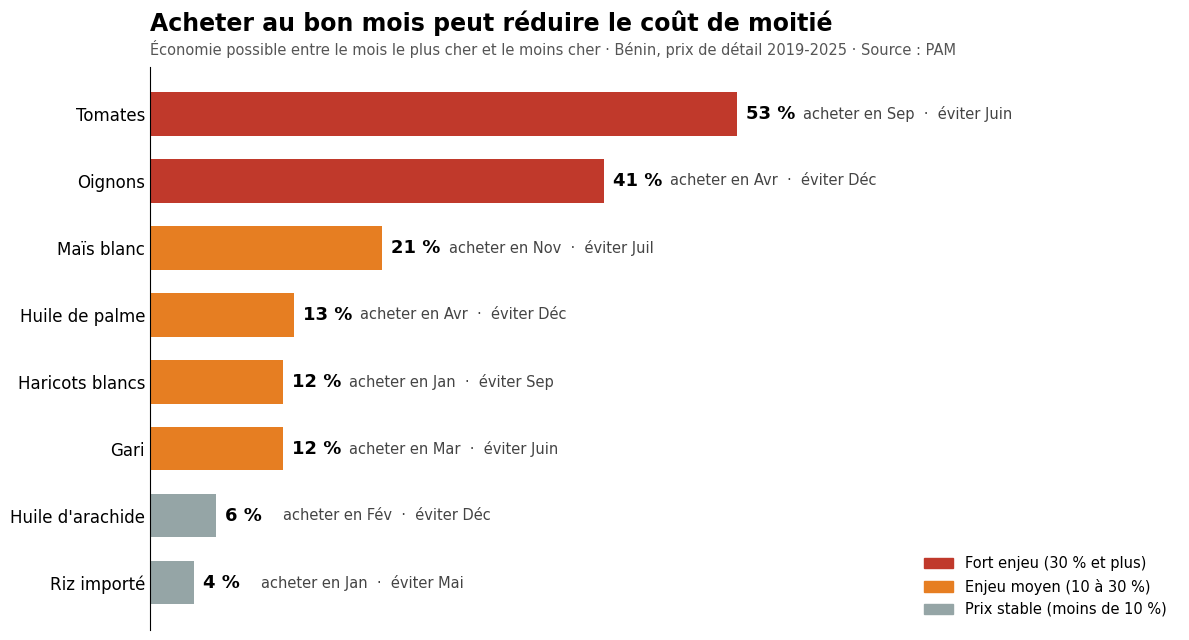

In [6]:
# Étape 4 bis : économie possible en achetant au bon moment (version décideur)
resume = pd.DataFrame({
    "Meilleur mois": saison.idxmin(axis=1),
    "Pire mois": saison.idxmax(axis=1),
    "Économie (%)": ((saison.max(axis=1) - saison.min(axis=1)) / saison.max(axis=1) * 100).round(0)
}).sort_values("Économie (%)")

def couleur(x):
    if x >= 30: return "#c0392b"   # fort enjeu
    if x >= 10: return "#e67e22"   # enjeu moyen
    return "#95a5a6"               # prix stable

fig, ax = plt.subplots(figsize=(12, 6.5))
barres = ax.barh(resume.index, resume["Économie (%)"],
                 color=[couleur(x) for x in resume["Économie (%)"]], height=0.65)

for b, (prod, l) in zip(barres, resume.iterrows()):
    y = b.get_y() + b.get_height() / 2
    ax.text(b.get_width() + 0.8, y, f"{l['Économie (%)']:.0f} %",
            va="center", fontsize=13, fontweight="bold")
    ax.text(b.get_width() + 6, y, f"acheter en {l['Meilleur mois']}  ·  éviter {l['Pire mois']}",
            va="center", fontsize=10.5, color="#444")

ax.set_title("Acheter au bon mois peut réduire le coût de moitié\n",
             fontsize=17, fontweight="bold", loc="left")
ax.text(0, 1.02, "Économie possible entre le mois le plus cher et le moins cher · Bénin, prix de détail 2019-2025 · Source : PAM",
        transform=ax.transAxes, fontsize=10.5, color="#555")

for cote in ["top", "right", "bottom"]:
    ax.spines[cote].set_visible(False)
ax.set_xticks([])
ax.tick_params(axis="y", labelsize=12, length=0)
ax.set_xlim(0, resume["Économie (%)"].max() + 40)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#c0392b", label="Fort enjeu (30 % et plus)"),
                   Patch(color="#e67e22", label="Enjeu moyen (10 à 30 %)"),
                   Patch(color="#95a5a6", label="Prix stable (moins de 10 %)")],
          loc="lower right", frameon=False, fontsize=10.5)
plt.tight_layout()
plt.show()

## 5. Où acheter ? Les écarts de prix entre départements
Prix de détail médian par département sur les 12 derniers mois disponibles (août 2025 à juillet 2026). La couleur compare chaque département à la médiane nationale : vert = moins cher, rouge = plus cher. Les chiffres affichés sont les prix en FCFA (par kg, ou par litre pour les huiles). La médiane limite l'effet des relevés extrêmes.

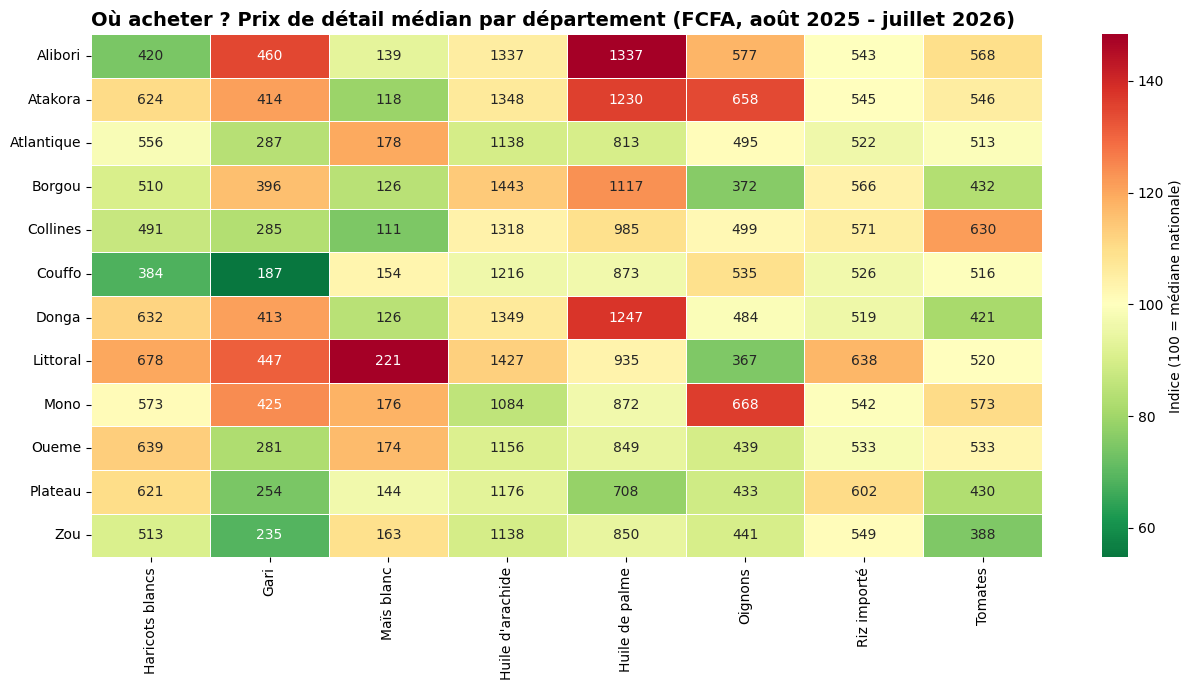

In [7]:
# Étape 5 : prix médian par département (12 derniers mois)
recent = df[(df["date"] >= "2025-08-01") & (df["commodity"].isin(produits))]
par_marche = recent.groupby(["commodity", "admin1", "market"])["price"].mean().reset_index()
dept = par_marche.groupby(["commodity", "admin1"])["price"].median().unstack().T.round(0)
dept.columns = dept.columns.map(produits)

indice_dept = dept / dept.median() * 100   # 100 = médiane nationale

plt.figure(figsize=(13, 7))
sns.heatmap(indice_dept, annot=dept, fmt=".0f", cmap="RdYlGn_r", center=100,
            cbar_kws={"label": "Indice (100 = médiane nationale)"}, linewidths=0.5)
plt.title("Où acheter ? Prix de détail médian par département (FCFA, août 2025 - juillet 2026)",
          fontsize=14, fontweight="bold", loc="left")
plt.xlabel(""); plt.ylabel("")
plt.tight_layout()
plt.show()

**Lecture :** les produits locaux suivent les zones de production. Le maïs est jusqu'à 2 fois moins cher dans le Centre et le Nord que dans le Littoral ; le gari et l'huile de palme sont moins chers dans le Sud. Le riz importé, distribué depuis le port, varie peu d'un département à l'autre.

                 Moins cher  Prix min Plus cher  Prix max  Écart (%)
commodity                                                           
Gari                 Couffo     187.0   Alibori     460.0      146.0
Maïs blanc         Collines     111.0  Littoral     221.0       99.0
Huile de palme      Plateau     708.0   Alibori    1337.0       89.0
Oignons            Littoral     367.0      Mono     668.0       82.0
Haricots blancs      Couffo     384.0  Littoral     678.0       77.0
Tomates                 Zou     388.0  Collines     630.0       62.0
Huile d'arachide       Mono    1084.0    Borgou    1443.0       33.0
Riz importé           Donga     519.0  Littoral     638.0       23.0


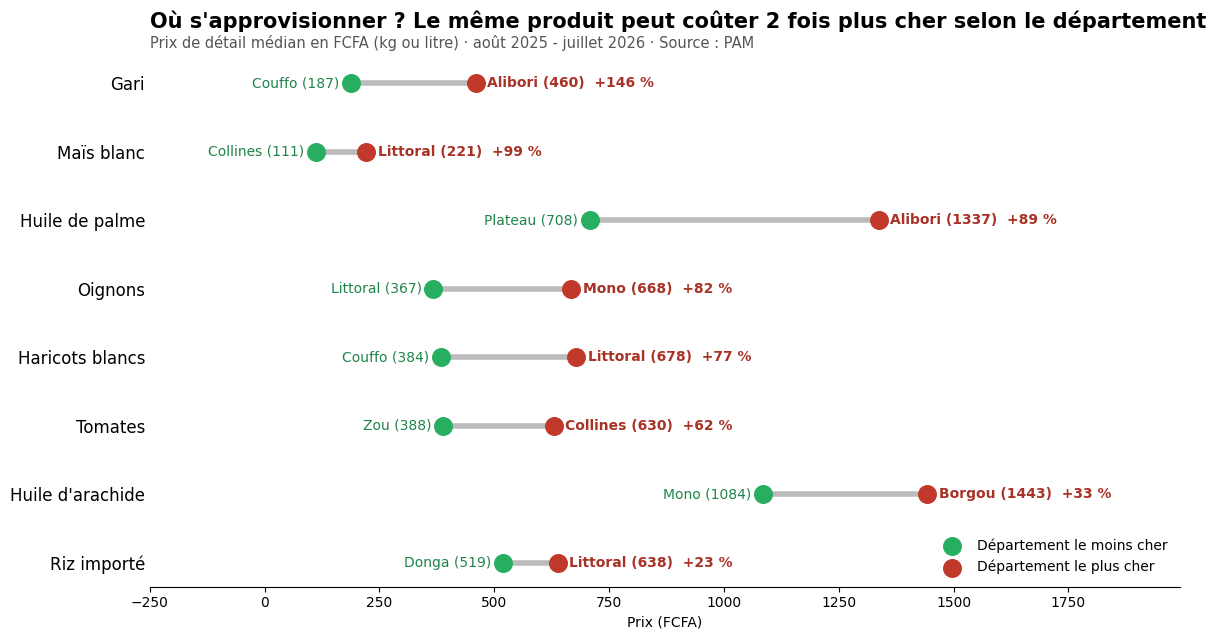

In [8]:
# Étape 5 bis : département le moins cher vs le plus cher
ecarts = pd.DataFrame({
    "Moins cher": dept.idxmin(), "Prix min": dept.min(),
    "Plus cher": dept.idxmax(), "Prix max": dept.max()})
ecarts["Écart (%)"] = ((ecarts["Prix max"] - ecarts["Prix min"]) / ecarts["Prix min"] * 100).round(0)
ecarts = ecarts.sort_values("Écart (%)")
print(ecarts.sort_values("Écart (%)", ascending=False))

fig, ax = plt.subplots(figsize=(12, 6.5))
y = range(len(ecarts))
ax.hlines(y, ecarts["Prix min"], ecarts["Prix max"], color="#bbb", linewidth=4)
ax.scatter(ecarts["Prix min"], y, color="#27ae60", s=160, zorder=3, label="Département le moins cher")
ax.scatter(ecarts["Prix max"], y, color="#c0392b", s=160, zorder=3, label="Département le plus cher")

for i, (prod, l) in enumerate(ecarts.iterrows()):
    ax.text(l["Prix min"] - 25, i, f"{l['Moins cher']} ({l['Prix min']:.0f})",
            ha="right", va="center", fontsize=10, color="#1e8449")
    ax.text(l["Prix max"] + 25, i, f"{l['Plus cher']} ({l['Prix max']:.0f})  +{l['Écart (%)']:.0f} %",
            ha="left", va="center", fontsize=10, color="#a93226", fontweight="bold")

ax.set_yticks(list(y)); ax.set_yticklabels(ecarts.index, fontsize=12)
ax.set_xlim(-250, ecarts["Prix max"].max() + 550)
ax.set_title("Où s'approvisionner ? Le même produit peut coûter 2 fois plus cher selon le département\n",
             fontsize=15, fontweight="bold", loc="left")
ax.text(0, 1.02, "Prix de détail médian en FCFA (kg ou litre) · août 2025 - juillet 2026 · Source : PAM",
        transform=ax.transAxes, fontsize=10.5, color="#555")
for cote in ["top", "right", "left"]:
    ax.spines[cote].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Prix (FCFA)")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

## 6. Quels produits sont risqués ? Importés ou locaux ?
Pour chaque produit, on calcule le prix médian national de chaque mois (2019-2026), puis la variation d'un mois à l'autre. Un « choc de prix » est une variation de plus de 10 % en un mois. Plus un produit subit de chocs, plus il est risqué pour la marge des commerçants.

/tmp/ipykernel_1241/1526114152.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  variation = national.pct_change() * 100


                  Chocs (% des mois)  Variation moyenne (%)
commodity                                                  
Tomates                         53.3                   15.5
Oignons                         43.3                   10.0
Maïs blanc                      15.6                    5.5
Huile de palme                  12.2                    4.3
Gari                            11.1                    4.9
Haricots blancs                  5.6                    3.9
Huile d'arachide                 4.4                    2.7
Riz importé                      1.1                    1.4


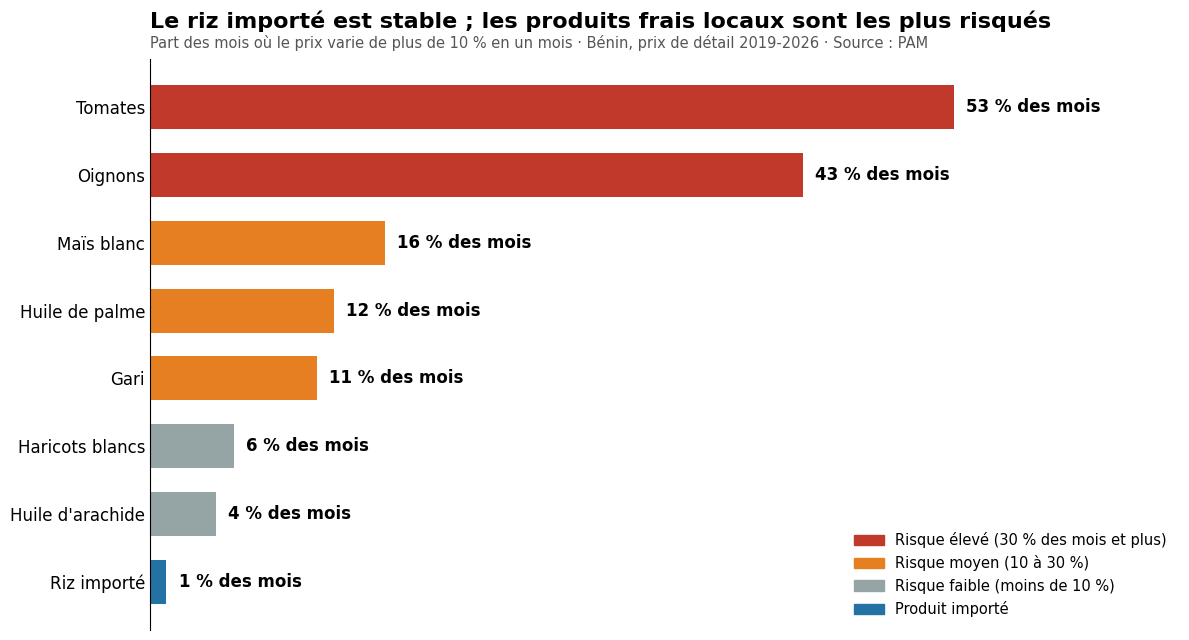

In [9]:
# Étape 6 : fréquence des chocs de prix (variation mensuelle > 10 %)
d6 = df[df["commodity"].isin(produits)]
national = d6.groupby(["commodity", "date"])["price"].median().unstack(0)
variation = national.pct_change() * 100

risque = pd.DataFrame({
    "Chocs (% des mois)": (variation.abs() > 10).mean() * 100,
    "Variation moyenne (%)": variation.abs().mean()
}).round(1)
risque.index = risque.index.map(produits)
risque = risque.sort_values("Chocs (% des mois)")
print(risque.sort_values("Chocs (% des mois)", ascending=False))

importes = ["Riz importé"]
couleurs = ["#2471a3" if p in importes else ("#c0392b" if v >= 30 else "#e67e22" if v >= 10 else "#95a5a6")
            for p, v in zip(risque.index, risque["Chocs (% des mois)"])]

fig, ax = plt.subplots(figsize=(12, 6.5))
barres = ax.barh(risque.index, risque["Chocs (% des mois)"], color=couleurs, height=0.65)
for b, (prod, l) in zip(barres, risque.iterrows()):
    ax.text(b.get_width() + 0.8, b.get_y() + b.get_height() / 2,
            f"{l['Chocs (% des mois)']:.0f} % des mois", va="center", fontsize=12, fontweight="bold")

ax.set_title("Le riz importé est stable ; les produits frais locaux sont les plus risqués\n",
             fontsize=16, fontweight="bold", loc="left")
ax.text(0, 1.02, "Part des mois où le prix varie de plus de 10 % en un mois · Bénin, prix de détail 2019-2026 · Source : PAM",
        transform=ax.transAxes, fontsize=10.5, color="#555")
for cote in ["top", "right", "bottom"]:
    ax.spines[cote].set_visible(False)
ax.set_xticks([]); ax.tick_params(axis="y", labelsize=12, length=0)
ax.set_xlim(0, risque["Chocs (% des mois)"].max() + 15)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#c0392b", label="Risque élevé (30 % des mois et plus)"),
                   Patch(color="#e67e22", label="Risque moyen (10 à 30 %)"),
                   Patch(color="#95a5a6", label="Risque faible (moins de 10 %)"),
                   Patch(color="#2471a3", label="Produit importé")],
          loc="lower right", frameon=False, fontsize=10.5)
plt.tight_layout()
plt.show()

## 7. Comment les prix ont-ils évolué depuis 2019 ?
Prix de détail médian national par année, pour chaque produit (2026 : janvier à juillet). Cette étape montre les tendances de fond et les périodes de flambée, avant de passer à la prévision.

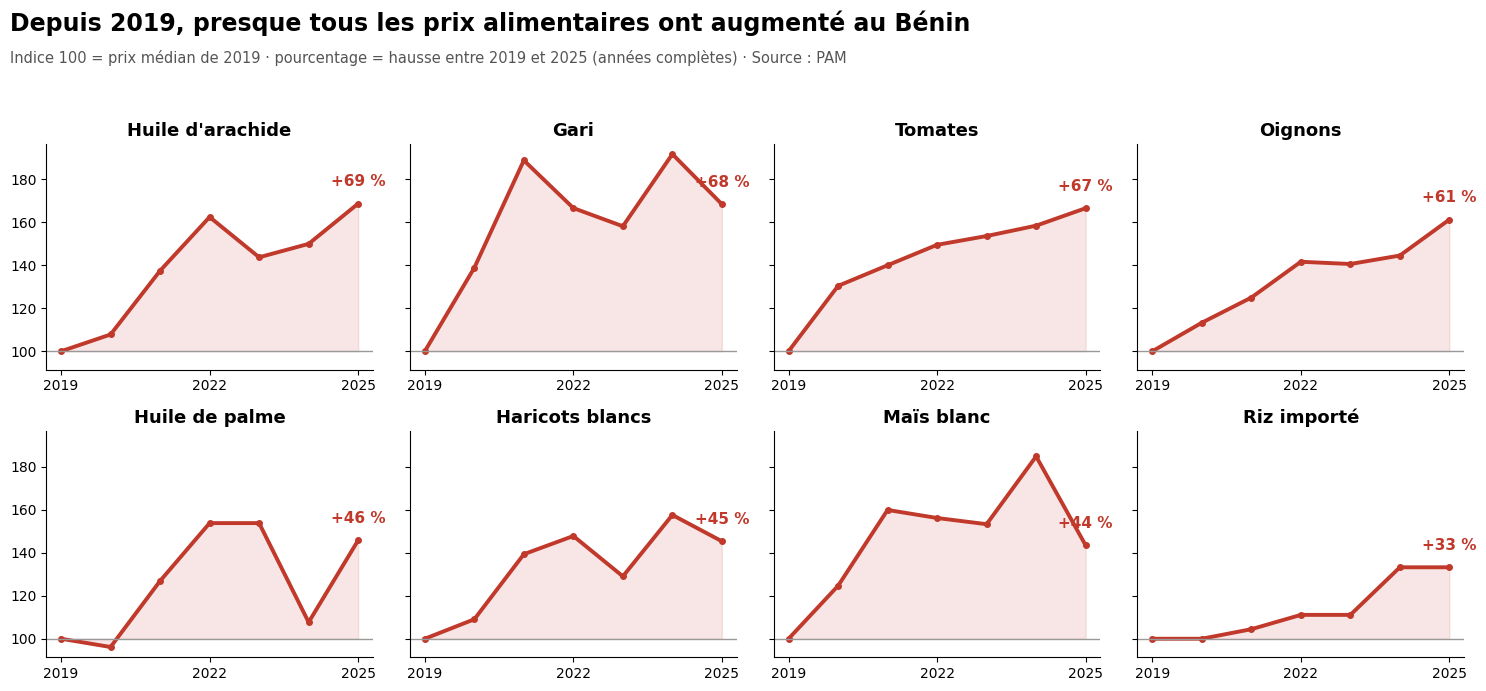

In [12]:
# Étape 7 : évolution des prix depuis 2019 (petits multiples, années complètes)
annuel = d6.groupby(["annee", "commodity"])["price"].median().unstack()
annuel.columns = annuel.columns.map(produits)
annuel = annuel.loc[2019:2025]   # années complètes uniquement
base100 = annuel / annuel.loc[2019] * 100   # 2019 = 100

ordre = base100.iloc[-1].sort_values(ascending=False).index   # du plus au moins augmenté
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=True)

for ax, prod in zip(axes.flat, ordre):
    serie = base100[prod]
    couleur = "#c0392b" if serie.iloc[-1] >= 130 else ("#e67e22" if serie.iloc[-1] >= 115 else "#2471a3")
    ax.plot(serie.index, serie, color=couleur, linewidth=2.8, marker="o", markersize=4)
    ax.fill_between(serie.index, 100, serie, color=couleur, alpha=0.12)
    ax.axhline(100, color="#999", linewidth=1)
    ax.set_title(prod, fontsize=13, fontweight="bold")
    ax.text(serie.index[-1], serie.iloc[-1] + 8, f"{serie.iloc[-1] - 100:+.0f} %",
            ha="center", fontsize=11, fontweight="bold", color=couleur)
    ax.set_xticks([2019, 2022, 2025])
    for cote in ["top", "right"]:
        ax.spines[cote].set_visible(False)

fig.suptitle("Depuis 2019, presque tous les prix alimentaires ont augmenté au Bénin",
             fontsize=17, fontweight="bold", x=0.01, ha="left")
fig.text(0.01, 0.905, "Indice 100 = prix médian de 2019 · pourcentage = hausse entre 2019 et 2025 (années complètes) · Source : PAM",
         fontsize=10.5, color="#555")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

**Lecture :** entre 2019 et 2025, tous les produits suivis ont augmenté, de +33 % pour le riz importé à près de +70 % pour l'huile d'arachide, le gari et les tomates.

## 8. À quoi s'attendre ? Tendance saisonnière août-octobre 2026
Méthode : on part du prix médian national de juillet 2026 (dernier mois connu) et on applique le profil saisonnier moyen observé en 2019-2025 (étape 4). Il s'agit d'une tendance attendue, pas d'une certitude : un choc (climat, fermeture de frontière, prix du carburant) peut la modifier.

                  Prix juillet 2026  Tendance Août (%)  Tendance Sep (%)  \
commodity                                                                  
Haricots blancs               553.0                4.0               5.0   
Gari                          254.0                0.0              -1.0   
Maïs blanc                    148.0               -5.0             -13.0   
Huile d'arachide             1212.0                0.0               0.0   
Huile de palme                825.0                0.0               2.0   
Oignons                       486.0                6.0              10.0   
Riz importé                   532.0                1.0               0.0   
Tomates                       522.0              -32.0             -42.0   

                  Tendance Oct (%)  
commodity                           
Haricots blancs                1.0  
Gari                          -4.0  
Maïs blanc                   -18.0  
Huile d'arachide              -1.0  
Huile de palme   

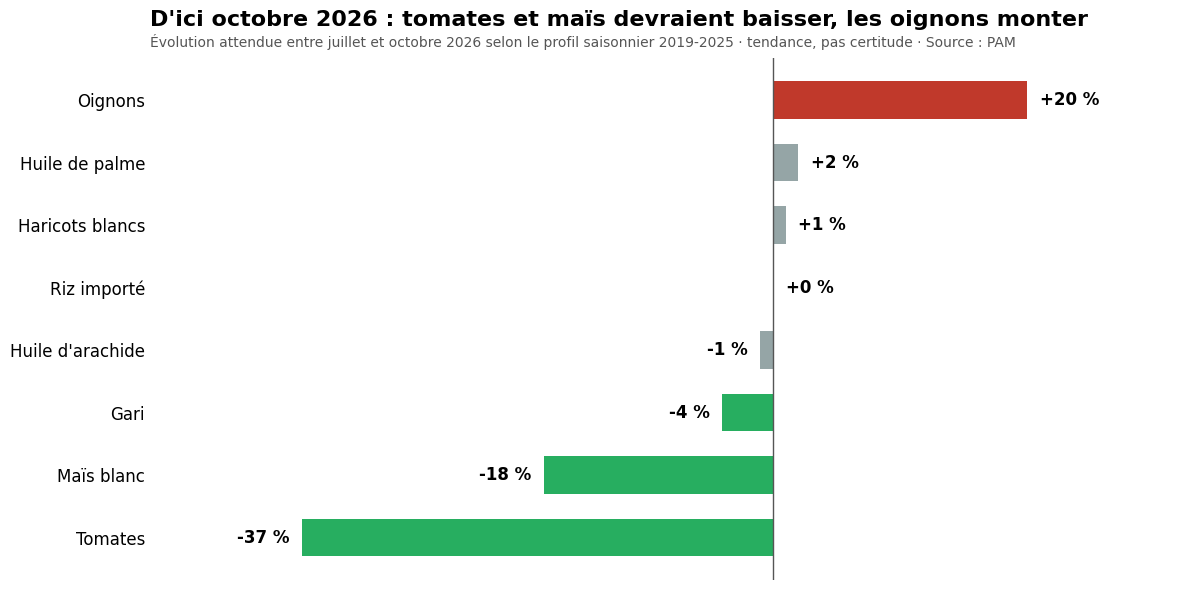

In [13]:
# Étape 8 : tendance saisonnière attendue (août à octobre 2026)
juillet = national.loc["2026-07-15"].rename(produits)
col = {8: "Août", 9: "Sep", 10: "Oct"}

prev = pd.DataFrame({"Prix juillet 2026": juillet.round(0)})
for m, nom in col.items():
    prev[f"Tendance {nom} (%)"] = ((saison[nom] / saison["Juil"] - 1) * 100).round(0)
print(prev)

oct_ = prev["Tendance Oct (%)"].sort_values()
couleurs = ["#27ae60" if v < -3 else ("#c0392b" if v > 3 else "#95a5a6") for v in oct_]

fig, ax = plt.subplots(figsize=(12, 6))
barres = ax.barh(oct_.index, oct_, color=couleurs, height=0.6)
for b, v in zip(barres, oct_):
    ax.text(v + (1 if v >= 0 else -1), b.get_y() + b.get_height() / 2, f"{v:+.0f} %",
            va="center", ha="left" if v >= 0 else "right", fontsize=12, fontweight="bold")
ax.axvline(0, color="#555", linewidth=1)
ax.set_title("D'ici octobre 2026 : tomates et maïs devraient baisser, les oignons monter\n",
             fontsize=16, fontweight="bold", loc="left")
ax.text(0, 1.02, "Évolution attendue entre juillet et octobre 2026 selon le profil saisonnier 2019-2025 · tendance, pas certitude · Source : PAM",
        transform=ax.transAxes, fontsize=10, color="#555")
for cote in ["top", "right", "bottom", "left"]:
    ax.spines[cote].set_visible(False)
ax.set_xticks([]); ax.tick_params(axis="y", labelsize=12, length=0)
ax.set_xlim(oct_.min() - 12, oct_.max() + 12)
plt.tight_layout()
plt.show()

## 9. Synthèse et recommandations

### Ce que montrent les données (Bénin, 2019-2026)
1. **Les prix ont fortement augmenté** : de +33 % (riz importé) à près de +70 % (huile d'arachide, gari, tomates) entre 2019 et 2025.
2. **Le moment d'achat compte** : acheter au bon mois permet d'économiser jusqu'à 53 % sur les tomates, 41 % sur les oignons et 21 % sur le maïs.
3. **Le lieu d'achat compte** : un même produit peut coûter plus de 2 fois plus cher selon le département (gari : +146 % entre le Couffo et l'Alibori ; maïs : +99 % entre les Collines et le Littoral).
4. **Le risque vient des produits frais locaux** : les tomates et les oignons subissent un choc de prix plus de 4 mois sur 10, contre 1 mois sur 100 pour le riz importé.

### Recommandations pour les importateurs, grossistes et supermarchés
- **Planifier les achats selon le calendrier saisonnier** : maïs en octobre-novembre, oignons en mars-avril, tomates en septembre.
- **S'approvisionner dans les zones de production** : maïs dans le Centre et le Nord, gari et huile de palme dans le Sud.
- **Limiter les stocks de produits frais** et prévoir des marges de sécurité sur les produits les plus instables.

### Recommandations pour les pouvoirs publics et les ONG
- **Surveiller en priorité** les produits et les départements où les prix sont les plus élevés et les plus instables.
- **Anticiper les périodes de soudure** (avril à juillet pour le maïs) pour les actions de soutien aux ménages.

### Limites
- Prix de **détail** uniquement (les prix de gros sont trop rares dans la source).
- Données disponibles **jusqu'en juillet 2026** ; la tendance août-octobre est une **projection saisonnière**, pas une certitude.

*Réalisation : Malick OKASSE, consultant Data Analytics & IA · Source : Programme alimentaire mondial (PAM), via HDX.*